## Day010 [Cont.]
### Softmax Regression

In [1]:
# import necessary libs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

### Generating synthetic dataset

In [2]:
import pandas as pd
from sklearn.datasets import make_gaussian_quantiles
# Construct dataset
X1, y1 = make_gaussian_quantiles(cov=3.,
                                 n_samples=10000, n_features=2,
                                 n_classes=3, random_state=1)
X1 = pd.DataFrame(X1,columns=['x','y'])
y1 = pd.Series(y1)

In [3]:
X1.shape, y1.shape

((10000, 2), (10000,))

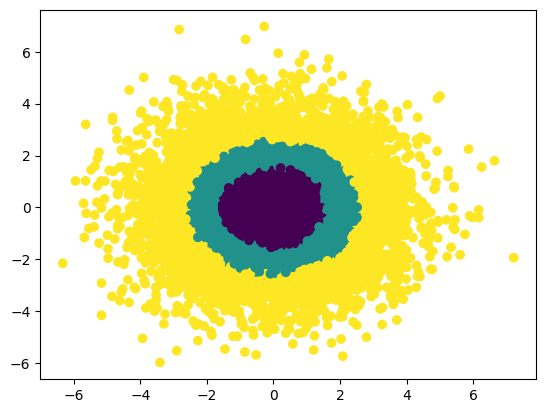

In [4]:
plt.scatter(X1.iloc[ :, 0 ], X1.iloc[ :, 1 ], c=y1)
plt.show()

While creating the dataset we use `DataFrame` therefore, fist we've to extact the numpy array from the above `DataFrame` objects.
<br/>
Below given code segment does the same.

In [5]:
X, y = X1.values, y1.values

From the above visualization we can clearly see that the decision boundary is non-linear. To handle that we first create non-linear features using `PolynomialFeatures` class of `sklearn` which helps in capturing the non-linear decision boundary.
<br/>
After adding polynomial features of degree 2, we scale the features using `StandardScaler` class.

In [6]:
poly_degree2 = PolynomialFeatures(degree=2)
X = poly_degree2.fit_transform(X)

In [7]:
std_scaler = StandardScaler()
X = std_scaler.fit_transform(X)

### Splitting dataset for training and testing

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=42,
                                                    test_size=0.3)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7000, 6), (3000, 6), (7000,), (3000,))

First, we try fitting our custom `SoftmaxRegression` class model and validates it's performance on testing dataset.

### Loading custom `SoftmaxRegression` class.

In [9]:
from softmax_regression import SoftmaxRegression

In [19]:
custom_softmax_regression_model = SoftmaxRegression(epochs=10000, learning_rate=1e-2)
custom_softmax_regression_model.fit(X_train, y_train)

In [20]:
custom_softmax_regression_predictions = custom_softmax_regression_model.predict(X_test)

### Evaluating peformance of custom `SoftmaxRegression` class using `f1_score`.

In [21]:
f1_score(y_test, custom_softmax_regression_predictions, average="weighted")

0.9413174528315681

Trying same, using `sklearn.linear_model.LogisticRegression` class

In [13]:
logistic_regression = LogisticRegression(multi_class="multinomial")
logistic_regression.fit(X_train, y_train)

C:\Users\papsr\anaconda3\envs\dl\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [14]:
logistic_regression_predictions = logistic_regression.predict(X_test)

### Evaluating peformance of `sklearn.linear_model.LogisticRegression` class using `f1_score`.

In [15]:
f1_score(y_test, logistic_regression_predictions, average="weighted")

0.9946669458547758

From the above results we can clearly see that the **LogisticRegression** class of `sklearn` perform better than our custom **SoftmaxRegression** class.
<br/>
The question arises **Why this happens?**
<br/>
1. Optimization
2. No Regularization
3. Convergence
4. Weak or Random initialization of weights.

### Visualizing the decision boundary

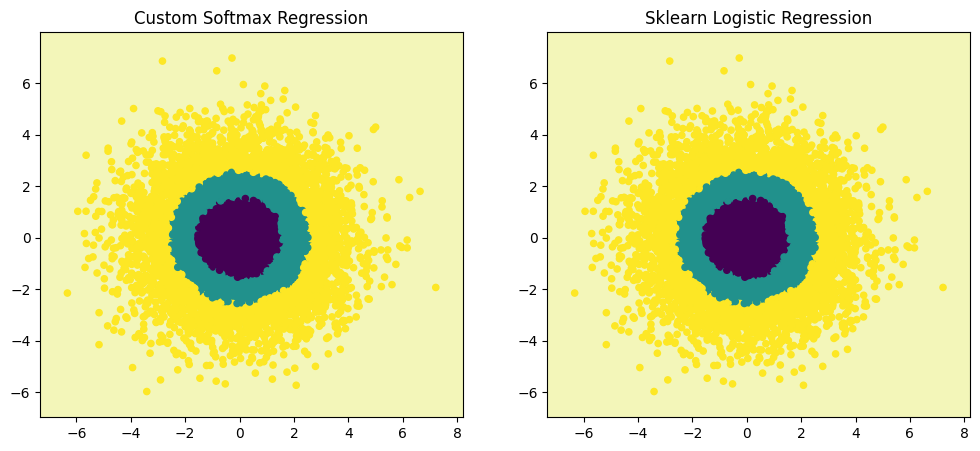

In [25]:
# ---- Step 1: Create meshgrid from ORIGINAL X ----
x_min, x_max = X1.iloc[:, 0].min() - 1, X1.iloc[:, 0].max() + 1
y_min, y_max = X1.iloc[:, 1].min() - 1, X1.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]


# ---- Step 2: Transform grid for CUSTOM model ----
grid_poly = poly_degree2.transform(grid)
grid_scaled = std_scaler.transform(grid_poly)

Z_custom = custom_softmax_regression_model.predict(grid_scaled)
Z_custom = Z_custom.reshape(xx.shape)


# ---- Step 3: Transform grid for SKLEARN model ----
# IMPORTANT: sklearn model was trained on transformed data
Z_sklearn = logistic_regression.predict(grid_scaled)
Z_sklearn = Z_sklearn.reshape(xx.shape)


# ---- Step 4: Plot side-by-side ----
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Custom model plot
ax[0].contourf(xx, yy, Z_custom, alpha=0.3, cmap='viridis')
ax[0].scatter(X1.iloc[:, 0], X1.iloc[:, 1], c=y, s=20)
ax[0].set_title("Custom Softmax Regression")

# Sklearn model plot
ax[1].contourf(xx, yy, Z_sklearn, alpha=0.3, cmap='viridis')
ax[1].scatter(X1.iloc[:, 0], X1.iloc[:, 1], c=y, s=20)
ax[1].set_title("Sklearn Logistic Regression")

plt.show()